# EX1

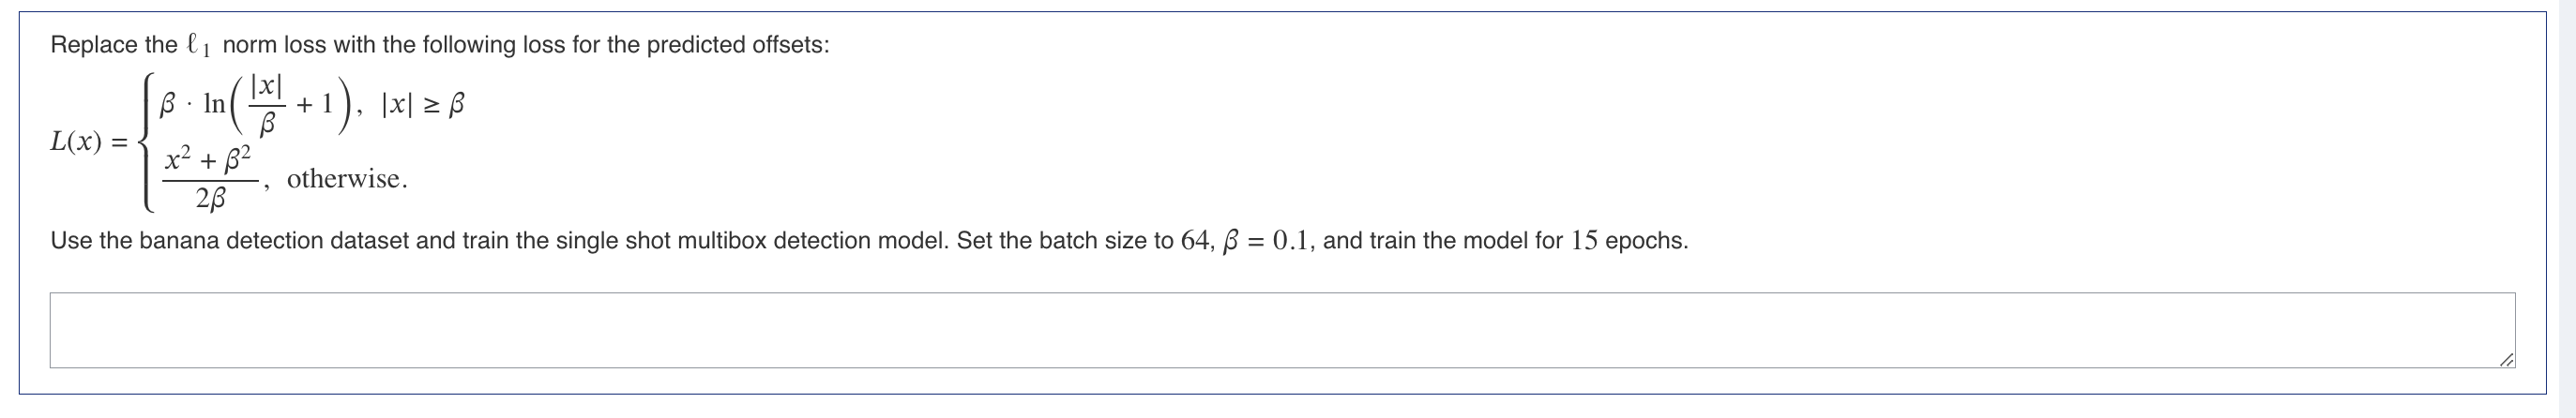

In [ ]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-


import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
import torchvision
from torchvision import transforms
import pandas as pd
import requests
import zipfile
from torch.utils.data import DataLoader, Dataset
import spacy
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence
import warnings
warnings.filterwarnings("ignore")

################################################################################
#                               UTILITY FUNCTIONS
################################################################################

def try_gpu(i=0):
    """Return cuda device i if available, else cpu."""
    return torch.device(f'cuda:{i}') if torch.cuda.device_count() > i else torch.device('cpu')

def download(url, cache_dir='data'):
    """Download file from `url` to `cache_dir`."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if not os.path.exists(fname):
        print(f'Downloading {url}...')
        r = requests.get(url, stream=True)
        with open(fname, 'wb') as f:
            f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url)
    base_dir = os.path.dirname(fname)
    if fname.endswith('.zip'):
        with zipfile.ZipFile(fname, 'r') as z:
            z.extractall(base_dir)
    if folder:
        return os.path.join(base_dir, folder)
    return base_dir

def read_data_bananas(is_train=True):
    """Reads the banana detection dataset (images & label.csv)."""
    data_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/banana-detection.zip')
    split = 'train' if is_train else 'val'
    csv_fname = os.path.join(data_dir, f'bananas_{split}', 'label.csv')
    df = pd.read_csv(csv_fname).set_index('img_name')
    features, labels = [], []
    for img_name, row in df.iterrows():
        img_path = os.path.join(data_dir, f'bananas_{split}', 'images', img_name)
        features.append(torchvision.io.read_image(img_path))
        # label: (class, x1, y1, x2, y2), scaled to 1.0 => we'll keep them [0,1] after dividing by 256
        labels.append(list(row))
    return features, torch.tensor(labels).unsqueeze(1) / 256  # shape(N,1,5)

class BananasDataset(Dataset):
    """Bananas dataset for detection."""
    def __init__(self, is_train=True):
        self.features, self.labels = read_data_bananas(is_train)
        print(f"Loaded {len(self.features)} {'training' if is_train else 'validation'} examples.")
    def __getitem__(self, idx):
        return (self.features[idx].float(), self.labels[idx])
    def __len__(self):
        return len(self.features)

def load_data_bananas(batch_size=64):
    """Returns DataLoader for train & val splits."""
    train_iter = DataLoader(BananasDataset(True), batch_size, shuffle=True)
    val_iter   = DataLoader(BananasDataset(False), batch_size)
    return train_iter, val_iter

######################## 2) TinySSD Model & Inference ##########################

def box_corner_to_center(boxes):
    x1, y1, x2, y2 = boxes[:,0], boxes[:,1], boxes[:,2], boxes[:,3]
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    w  = x2 - x1
    h  = y2 - y1
    return torch.stack((cx, cy, w, h), axis=-1)

def box_center_to_corner(boxes):
    cx, cy, w, h = boxes[:,0], boxes[:,1], boxes[:,2], boxes[:,3]
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    return torch.stack((x1, y1, x2, y2), axis=-1)

def multibox_prior(data, sizes, ratios):
    """Generate anchor boxes with different sizes & aspect ratios for each pixel."""
    in_h, in_w = data.shape[-2:]
    device, num_sizes, num_ratios = data.device, len(sizes), len(ratios)
    boxes_per_pixel = (num_sizes + num_ratios - 1)
    size_tensor = torch.tensor(sizes, device=device)
    ratio_tensor= torch.tensor(ratios,device=device)
    offset_h, offset_w = 0.5, 0.5
    steps_h = 1.0/in_h
    steps_w = 1.0/in_w
    center_h = (torch.arange(in_h, device=device)+offset_h)*steps_h
    center_w = (torch.arange(in_w, device=device)+offset_w)*steps_w
    shift_y, shift_x = torch.meshgrid(center_h, center_w, indexing='ij')
    shift_y, shift_x = shift_y.reshape(-1), shift_x.reshape(-1)
    w = torch.cat((size_tensor*torch.sqrt(ratio_tensor[0]),
                   sizes[0]*torch.sqrt(ratio_tensor[1:]))) * in_h/in_w
    h = torch.cat((size_tensor/torch.sqrt(ratio_tensor[0]),
                   sizes[0]/torch.sqrt(ratio_tensor[1:])))
    anchor_manipulations = torch.stack(
        [-w,-h,w,h]).T.repeat(in_h*in_w,1)/2
    out_grid = torch.stack([shift_x, shift_y,
                            shift_x, shift_y],dim=1)
    output = out_grid+anchor_manipulations
    return output.unsqueeze(0)

def flatten_pred(pred):
    """Flattens from [N, out_channels, H, W] -> [N, H*W, out_channels]."""
    return pred.permute(0,2,3,1).reshape(pred.shape[0],-1,pred.shape[1])

def concat_preds(preds):
    return torch.cat([flatten_pred(p) for p in preds], dim=1)

class TinySSD(nn.Module):
    """A tiny Single Shot Multibox Detection model."""
    def __init__(self, num_classes):
        super().__init__()
        # Anchor hyperparams
        self.num_classes = num_classes
        self.sizes  = [[0.2,0.272],[0.37,0.447],[0.54,0.619],[0.71,0.79],[0.88,0.961]]
        self.ratios = [[1,2,0.5]]*5
        self.num_anchors = len(self.sizes[0]) + len(self.ratios[0]) -1

        # Stages
        idx_channels = [64, 128, 128, 128, 128]
        # create blocks + predictor heads
        for i in range(5):
            setattr(self, f'blk_{i}', self.get_block(i))
            setattr(self, f'cls_{i}', self.cls_predictor(idx_channels[i], self.num_anchors, self.num_classes))
            setattr(self, f'bbox_{i}', self.bbox_predictor(idx_channels[i], self.num_anchors))

    def get_block(self, i):
        """Return the i-th stage's block."""
        def down_sample_blk(in_ch, out_ch):
            block=[]
            for _ in range(2):
                block.append(nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1))
                block.append(nn.BatchNorm2d(out_ch))
                block.append(nn.ReLU())
                in_ch = out_ch
            block.append(nn.MaxPool2d(2))
            return nn.Sequential(*block)

        def base_net():
            b=[]
            channels=[3,16,32,64]
            for j in range(len(channels)-1):
                b.append(down_sample_blk(channels[j], channels[j+1]))
            return nn.Sequential(*b)

        if i==0:
            return base_net()
        elif i==1:
            return down_sample_blk(64,128)
        elif i==4:
            return nn.AdaptiveMaxPool2d((1,1))
        else:
            return down_sample_blk(128,128)

    def cls_predictor(self, in_ch, num_anchors, num_classes):
        return nn.Conv2d(in_ch, num_anchors*(num_classes+1), kernel_size=3, padding=1)

    def bbox_predictor(self, in_ch, num_anchors):
        return nn.Conv2d(in_ch, num_anchors*4, kernel_size=3, padding=1)

    def forward(self, X):
        anchors, cls_preds, bbox_preds = [], [], []
        for i in range(5):
            X = getattr(self, f'blk_{i}')(X)
            anchors.append(multibox_prior(X, self.sizes[i], self.ratios[i]))
            cls_preds.append(getattr(self, f'cls_{i}')(X))
            bbox_preds.append(getattr(self, f'bbox_{i}')(X))
        anchors = torch.cat(anchors, dim=1)
        cls_preds= concat_preds(cls_preds).reshape(X.shape[0], -1, self.num_classes+1)
        bbox_preds= concat_preds(bbox_preds)
        return anchors, cls_preds, bbox_preds

#################### 3) Labeling & Custom Piecewise Loss #######################

def box_iou(boxes1, boxes2):
    area = lambda b: (b[:,2]-b[:,0])*(b[:,3]-b[:,1])
    areas1 = area(boxes1)
    areas2 = area(boxes2)
    inter_ul = torch.max(boxes1[:,None,:2], boxes2[:,:2])
    inter_lr = torch.min(boxes1[:,None,2:], boxes2[:,2:])
    inter_wh= (inter_lr - inter_ul).clamp(min=0)
    inter   = inter_wh[:,:,0]*inter_wh[:,:,1]
    union   = areas1[:,None]+areas2 - inter
    return inter/union

def assign_anchor_to_bbox(gt, anchors, device, iou_threshold=0.5):
    num_anchors, num_gt= anchors.shape[0], gt.shape[0]
    jaccard = box_iou(anchors, gt)
    anchors_bbox_map = torch.full((num_anchors,), -1, dtype=torch.long, device=device)
    max_ious, indices= torch.max(jaccard, dim=1)
    anc_i = torch.nonzero(max_ious>=iou_threshold).reshape(-1)
    box_j= indices[max_ious>=iou_threshold]
    anchors_bbox_map[anc_i] = box_j
    col_discard= torch.full((num_anchors,), -1)
    row_discard= torch.full((num_gt,), -1)
    for _ in range(num_gt):
        max_idx= torch.argmax(jaccard)
        box_idx= (max_idx%num_gt).long()
        anc_idx= (max_idx/num_gt).long()
        anchors_bbox_map[anc_idx] = box_idx
        jaccard[:, box_idx] = col_discard
        jaccard[anc_idx,: ] = row_discard
    return anchors_bbox_map

def offset_boxes(anchors, assigned_bb, eps=1e-6):
    c_anc= box_corner_to_center(anchors)
    c_ass= box_corner_to_center(assigned_bb)
    offset_xy= 10*(c_ass[:,:2]-c_anc[:,:2]) / c_anc[:,2:]
    offset_wh= 5*torch.log(eps + c_ass[:,2:]/ c_anc[:,2:])
    return torch.cat([offset_xy, offset_wh], axis=1)

def multibox_target(anc, label):
    """Label anchors with ground truth bounding boxes."""
    batch_size, device= label.shape[0], anc.device
    anc= anc.squeeze(0)
    batch_offset, batch_mask, batch_cls= [], [], []
    for i in range(batch_size):
        gt= label[i,:,1:]
        anchors_bbox_map= assign_anchor_to_bbox(gt, anc, device)
        bbox_mask= (anchors_bbox_map>=0).float().unsqueeze(-1).repeat(1,4)
        cls_label= torch.zeros(anc.shape[0], dtype=torch.long, device=device)
        assigned_bb= torch.zeros((anc.shape[0],4), dtype=torch.float32, device=device)
        indices_true= torch.nonzero(anchors_bbox_map>=0).reshape(-1)
        bb_idx= anchors_bbox_map[indices_true]
        cls_label[indices_true] = label[i,bb_idx,0].long()+1
        assigned_bb[indices_true]= label[i,bb_idx,1:]
        offset = offset_boxes(anc, assigned_bb)* bbox_mask
        batch_offset.append(offset.reshape(-1))
        batch_mask.append(bbox_mask.reshape(-1))
        batch_cls.append(cls_label)
    bbox_offset= torch.stack(batch_offset)
    bbox_mask  = torch.stack(batch_mask)
    class_label= torch.stack(batch_cls)
    return (bbox_offset, bbox_mask, class_label)

################### Custom Piecewise Function for Offsets ######################

def piecewise_offset_loss(x, beta=0.1):
    """
    L(x) =  beta * ln(|x|/beta + 1)        if |x| >= beta
            (x^2 + beta^2) / (2 * beta)   otherwise
    """
    abs_x = x.abs()
    big_mask = (abs_x >= beta)
    out = torch.zeros_like(x)
    # region where |x| >= beta:
    out[big_mask] = beta * torch.log( (abs_x[big_mask]/beta) + 1.0 )
    # region where |x| < beta:
    out[~big_mask] = ( x[~big_mask]**2 + beta**2 ) / (2*beta)
    return out

def custom_bbox_loss(bbox_preds, bbox_labels, bbox_masks, beta=0.1):
    """
    We compute piecewise_offset_loss for each coordinate, then average.
    bbox_preds, bbox_labels, bbox_masks shape => (batch_size, num_anchors*4)
    """
    x = (bbox_preds - bbox_labels)* bbox_masks
    # shape => (batch_size, num_anchors*4), apply piecewise
    loss = piecewise_offset_loss(x, beta=beta)
    # average per sample => shape (batch_size)
    return loss.mean(dim=1)

################### Combined Loss: Class + BBox using piecewise #################

def calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels, bbox_masks, beta=0.1):
    """Classification Loss + Custom offset loss."""
    # classification: cross-entropy
    batch_size, num_classes = cls_preds.shape[0], cls_preds.shape[2]
    cls = F.cross_entropy(cls_preds.reshape(-1, num_classes),
                          cls_labels.reshape(-1),
                          reduction='none').view(batch_size,-1).mean(dim=1)
    # bounding boxes:
    bbox = custom_bbox_loss(bbox_preds, bbox_labels, bbox_masks, beta=beta)
    return cls + bbox  # shape (batch_size,)

def cls_eval(cls_preds, cls_labels):
    return (cls_preds.argmax(dim=-1).type(cls_labels.dtype)==cls_labels).sum().item()

def bbox_eval(bbox_preds, bbox_labels, bbox_masks):
    return ((bbox_preds - bbox_labels)* bbox_masks).abs().sum().item()

################## 4) Training the Banana Detector #############################

def train_banana_detector(net, train_iter, num_epochs=15, beta=0.1, lr=0.2):
    device= try_gpu()
    net.to(device)
    optimizer= torch.optim.SGD(net.parameters(), lr=lr, weight_decay=5e-4)
    cls_acc_list, bbox_mae_list = [], []
    for epoch in range(num_epochs):
        net.train()
        total_cls, total_cls_labels= 0,0
        total_bbox, total_bbox_labels= 0,0
        for X, label in train_iter:
            X, label = X.to(device), label.to(device)
            optimizer.zero_grad()
            anchors, cls_preds, bbox_preds= net(X)
            bbox_labels, bbox_masks, cls_labels= multibox_target(anchors, label)
            losses= calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels, bbox_masks, beta=beta)
            l= losses.mean()
            l.backward()
            optimizer.step()
            with torch.no_grad():
                total_cls += cls_eval(cls_preds, cls_labels)
                total_cls_labels += cls_labels.numel()
                total_bbox += bbox_eval(bbox_preds, bbox_labels, bbox_masks)
                total_bbox_labels += bbox_labels.numel()
        cls_acc = (total_cls / total_cls_labels)*100
        bbox_mae= total_bbox / total_bbox_labels
        cls_acc_list.append(cls_acc)
        bbox_mae_list.append(bbox_mae)
        print(f"Epoch {epoch+1} -> cls acc={cls_acc:.2f}%, bbox MAE={bbox_mae:.2e}")
    return cls_acc_list, bbox_mae_list

# EX2

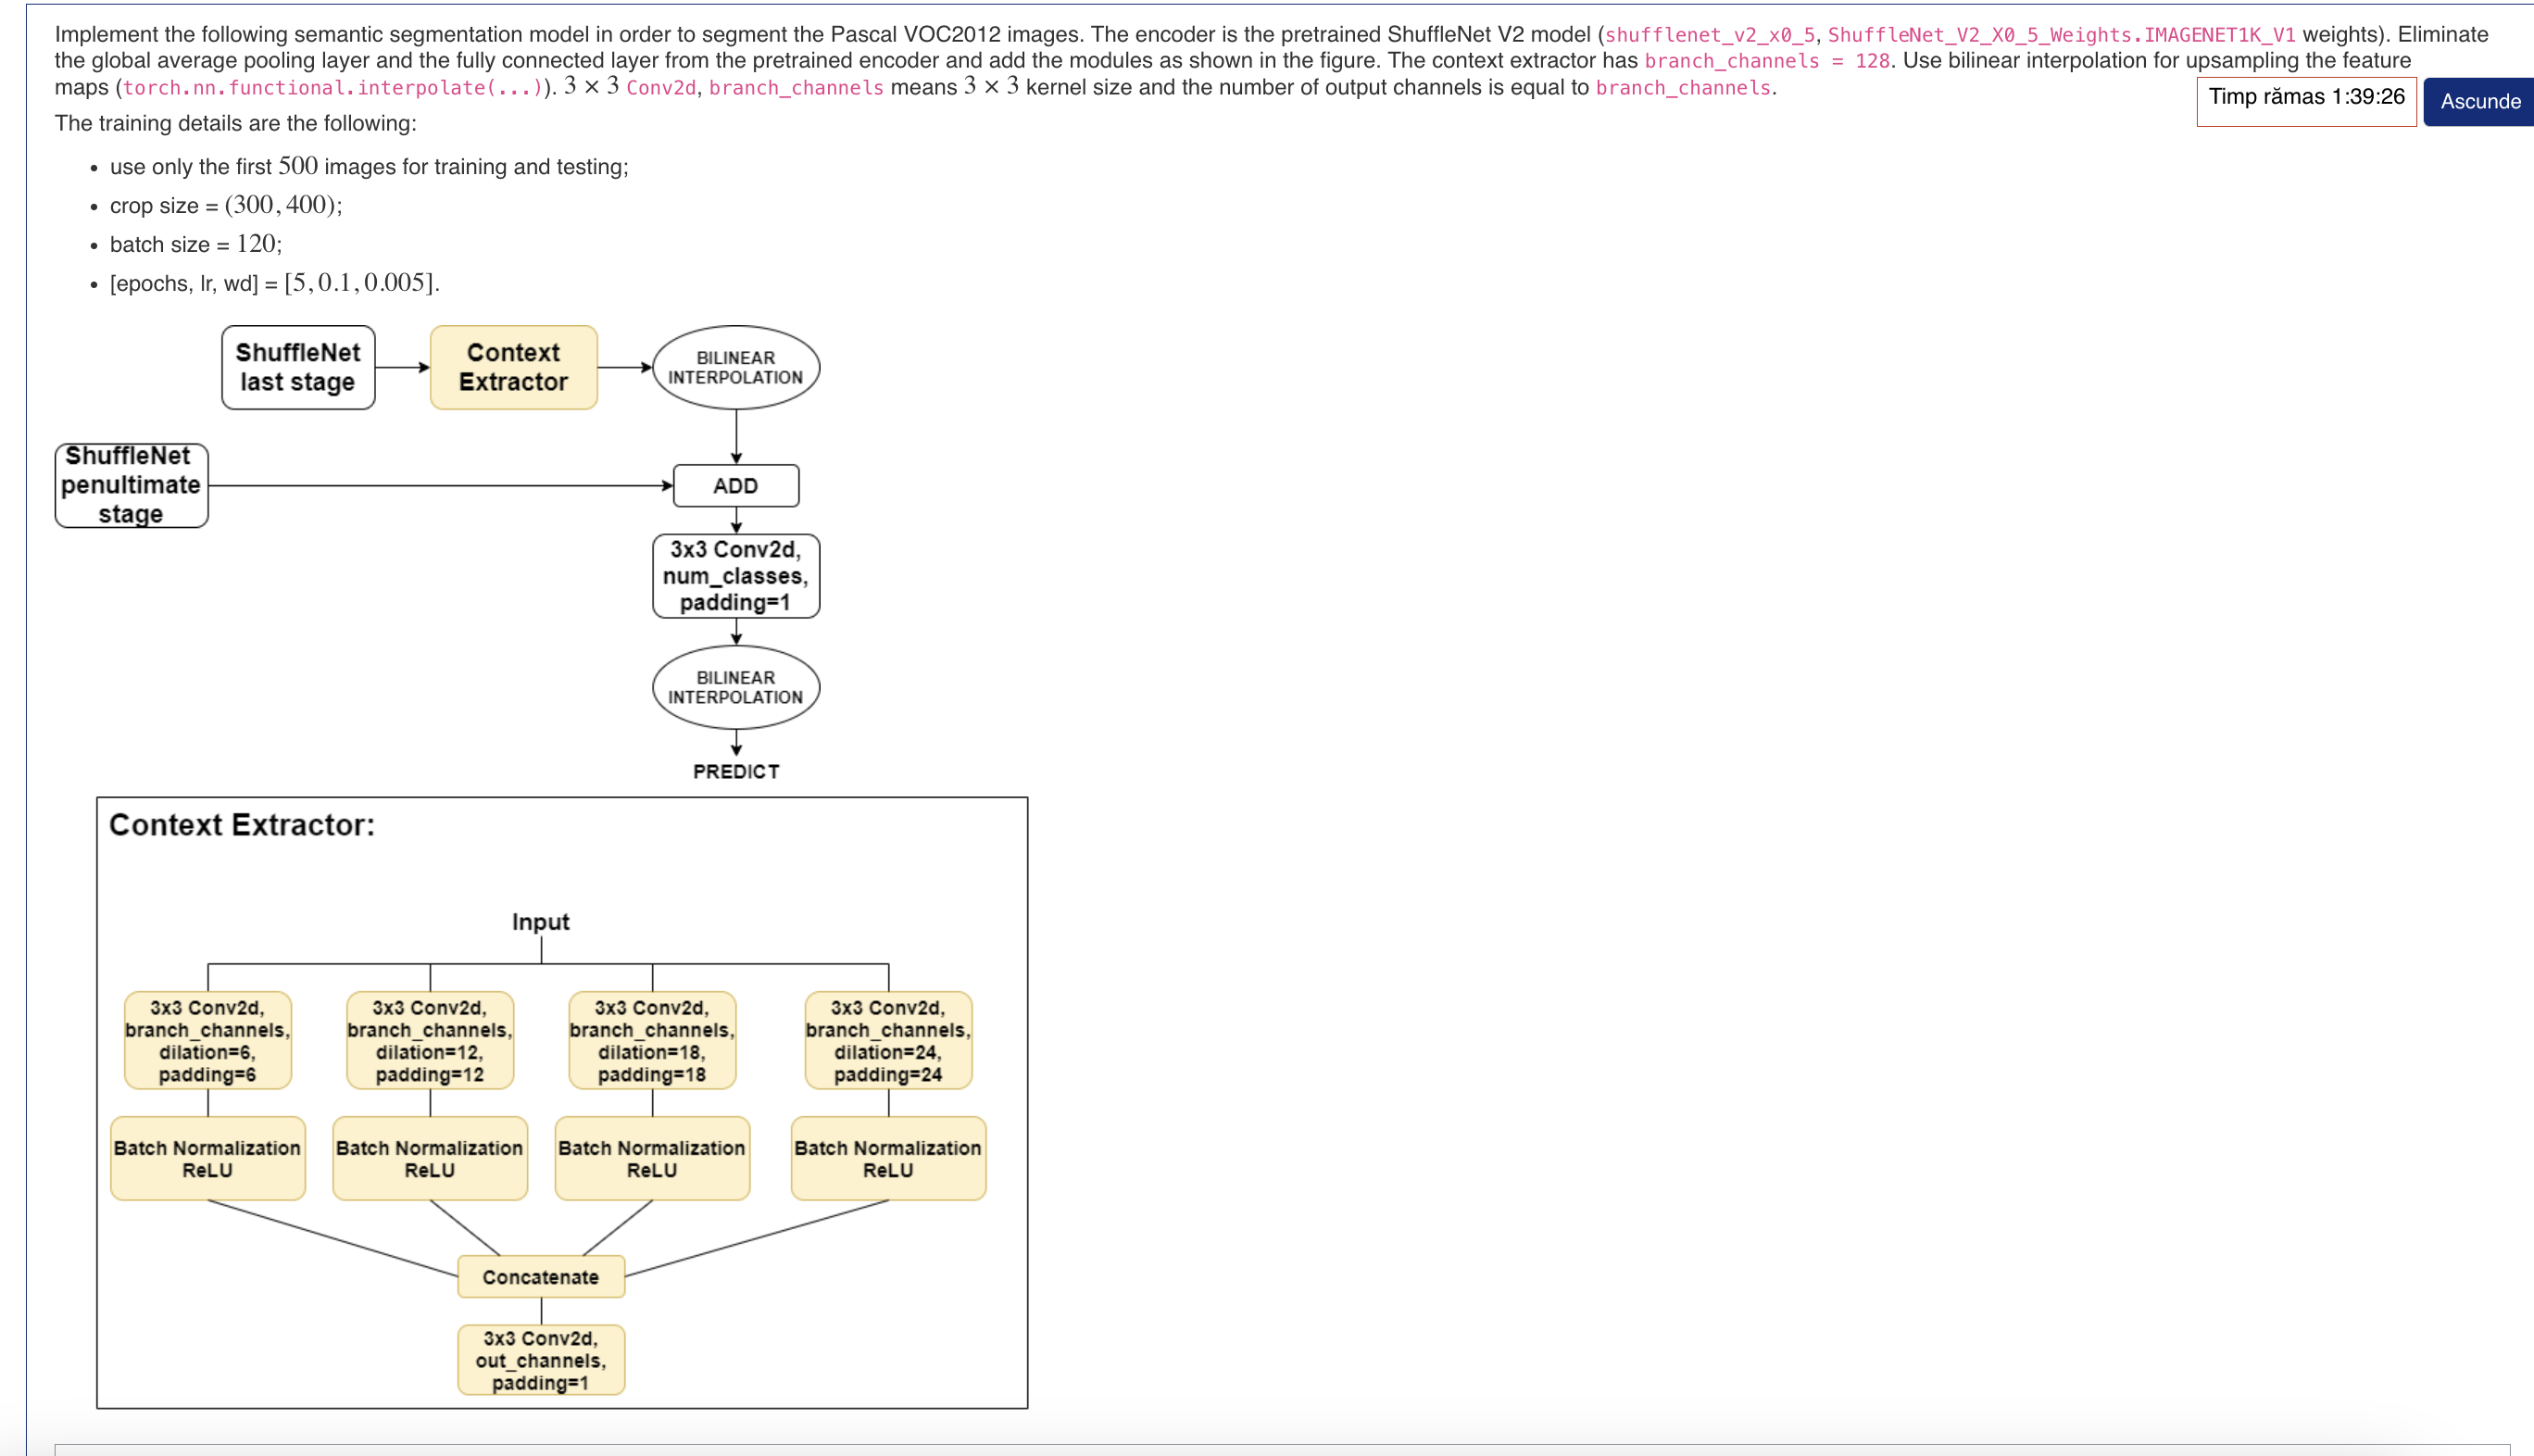

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

class ContextExtractor(nn.Module):
    def __init__(self, branch_channels=128):
        super(ContextExtractor, self).__init__()
        self.branch1 = nn.Sequential(
            nn.Conv2d(branch_channels, branch_channels, kernel_size=3, dilation=6, padding=6),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(True)
        )
        self.branch2 = nn.Sequential(
            nn.Conv2d(branch_channels, branch_channels, kernel_size=3, dilation=12, padding=12),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(True)
        )
        self.branch3 = nn.Sequential(
            nn.Conv2d(branch_channels, branch_channels, kernel_size=3, dilation=18, padding=18),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(True)
        )
        self.branch4 = nn.Sequential(
            nn.Conv2d(branch_channels, branch_channels, kernel_size=3, dilation=24, padding=24),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(True)
        )
        self.out_conv = nn.Sequential(
            nn.Conv2d(branch_channels * 4, branch_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(True)
        )

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)
        out = torch.cat([b1, b2, b3, b4], dim=1)
        return self.out_conv(out)

class ShuffleNetV2PlusContext(nn.Module):
    def __init__(self, num_classes=21, branch_channels=128):
        super(ShuffleNetV2PlusContext, self).__init__()
        shufflenet = torchvision.models.shufflenet_v2_x0_5(weights=torchvision.models.ShuffleNet_V2_X0_5_Weights.IMAGENET1K_V1)
        # Remove the global pool & classifier
        self.stage1 = nn.Sequential(
            shufflenet.conv1,  # (in->24)
            shufflenet.maxpool
        )
        self.stage2 = shufflenet.stage2  # penultimate stage
        self.stage3 = shufflenet.stage3  # last stage
        # Eliminate the global avgpool and fc from stage4
        self.context_extractor = ContextExtractor(branch_channels)
        self.class_conv = nn.Conv2d(num_classes, num_classes, kernel_size=3, padding=1)

        self.num_classes = num_classes
        self.branch_channels = branch_channels
        self.final_conv = nn.Conv2d(branch_channels, num_classes, kernel_size=3, padding=1)

    def forward(self, x):
        # ShuffleNet penultimate stage
        x = self.stage1(x)            # -> partial features
        penultimate_feats = self.stage2(x)  # penultimate
        last_feats = self.stage3(penultimate_feats)  # last stage

        # Context Extractor on the last_feats
        ctx = self.context_extractor(last_feats)
        # Upsample context to match shape of penultimate_feats
        ctx_up = F.interpolate(ctx, size=penultimate_feats.shape[2:], mode='bilinear', align_corners=False)
        # Add with penultimate features
        fused = penultimate_feats + ctx_up
        # 3x3 conv => num_classes
        fused = self.final_conv(fused)
        # Upsample to input size, predict
        out = F.interpolate(fused, scale_factor=4.0, mode='bilinear', align_corners=False)
        return out

# EX3

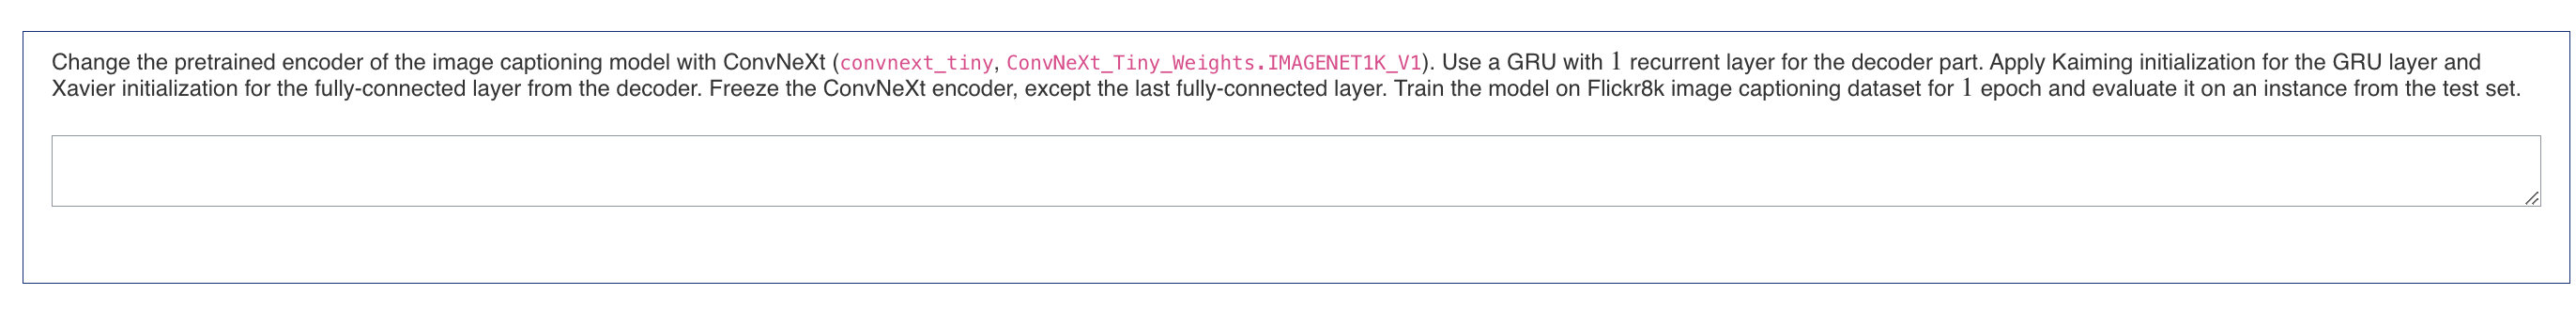

In [ ]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import transforms
import pandas as pd
import requests
import zipfile
from torch.utils.data import DataLoader, Dataset
import spacy
from torch.nn.utils.rnn import pad_sequence
from PIL import Image
import matplotlib.pyplot as plt
import logging
from io import BytesIO
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Initialize SpaCy English tokenizer
spacy_en = spacy.load("en_core_web_sm")

def try_gpu():
    """Returns the available device ('cuda' or 'cpu')."""
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def download_and_extract(url, extract_to='data'):
    """
    Downloads and extracts a ZIP file from the given URL.

    Args:
        url (str): URL to download the ZIP file from.
        extract_to (str): Directory to extract the contents to.
    """
    local_filename = url.split('/')[-1]
    local_filepath = os.path.join(extract_to, local_filename)

    if not os.path.exists(extract_to):
        os.makedirs(extract_to, exist_ok=True)

    if not os.path.exists(local_filepath):
        logging.info(f"Downloading from {url}...")
        response = requests.get(url, stream=True)
        if response.status_code == 200:
            with open(local_filepath, 'wb') as f:
                for chunk in response.iter_content(chunk_size=1024):
                    if chunk:
                        f.write(chunk)
            logging.info("Download completed.")
        else:
            logging.error(f"Failed to download data. Status code: {response.status_code}")
            raise Exception("Download failed.")
    else:
        logging.info(f"File {local_filename} already exists. Skipping download.")

    # Extract the ZIP file
    logging.info(f"Extracting {local_filename}...")
    with zipfile.ZipFile(local_filepath, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    logging.info(f"Extraction completed. Files are in '{extract_to}' directory.")

class Vocabulary:
    """Simple vocabulary for tokenizing text."""
    def __init__(self, freq_threshold):
        self.itos = {0:"<PAD>", 1:"<BOS>", 2:"<EOS>", 3:"<UNK>"}
        self.stoi = {"<PAD>":0, "<BOS>":1, "<EOS>":2, "<UNK>":3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    def tokenizer_eng(self, text):
        return [tok.text.lower() for tok in spacy_en.tokenizer(text)]

    def build_vocabulary(self, sentence_list):
        freq = {}
        idx  = 4
        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                freq[word] = freq.get(word,0)+1
                if freq[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx]  = word
                    idx +=1

    def numericalize(self, text):
        tokens = self.tokenizer_eng(text)
        return [self.stoi.get(tok, self.stoi["<UNK>"]) for tok in tokens]

def load_captions(path):
    """Load all captions from a txt file with format: image_id#caption_id \t caption."""
    out = []
    with open(path, "r", encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 2:
                caption = parts[1].strip()
                out.append(caption)
    return out

class FlickrDataset(Dataset):
    """Flickr8k dataset, reading from local .jpg images + captions txt."""
    def __init__(self, root_dir, captions_file, vocab, transform=None):
        """
        Args:
            root_dir (str): Directory with all the images.
            captions_file (str): Path to the captions file.
            vocab (Vocabulary): Vocabulary object.
            transform (callable, optional): Optional transform to be applied on an image.
        """
        self.root_dir = root_dir
        self.df = pd.read_csv(captions_file, sep="\t", names=["image", "caption"], header=None)
        self.vocab = vocab
        self.transform = transform
        self.imgs = self.df["image"].values
        self.captions = self.df["caption"].values

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        caption = self.captions[idx]
        img_id = self.imgs[idx].split('#')[0]  # Remove #caption_id
        path = os.path.join(self.root_dir, img_id)
        if not os.path.exists(path):
            raise FileNotFoundError(f"{path} not found.")
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        # numericalize
        tokens = [self.vocab.stoi["<BOS>"]]
        tokens += self.vocab.numericalize(caption)
        tokens.append(self.vocab.stoi["<EOS>"])
        return img, torch.tensor(tokens)

class CollateFn:
    """Collate for Flickr dataset, pads captions."""
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx
    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)
        targets = [item[1] for item in batch]
        targets = pad_sequence(targets, batch_first=False, padding_value=self.pad_idx)
        return imgs, targets

def get_loader(root_dir, captions_file, vocab, transform, batch_size=32, shuffle=True):
    """
    Creates DataLoader for Flickr8k dataset.

    Args:
        root_dir (str): Directory with all the images.
        captions_file (str): Path to the captions file.
        vocab (Vocabulary): Vocabulary object.
        transform (callable): Transformations to apply to images.
        batch_size (int): Batch size.
        shuffle (bool): Whether to shuffle the data.

    Returns:
        DataLoader: DataLoader for the dataset.
    """
    ds = FlickrDataset(root_dir, captions_file, vocab, transform=transform)
    pad_idx = ds.vocab.stoi["<PAD>"]
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      collate_fn=CollateFn(pad_idx))

class EncoderConvNeXtTiny(nn.Module):
    def __init__(self, embed_size):
        super().__init__()
        weights = torchvision.models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        self.model = torchvision.models.convnext_tiny(weights=weights)
        # Replace final classifier with linear->embed_size
        in_feats = self.model.classifier[2].in_features
        self.model.classifier[2] = nn.Linear(in_feats, embed_size)
        # Freeze except the last layer
        for name, param in self.model.named_parameters():
            if "classifier.2" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.model(x)
        return self.dropout(self.relu(x))

class DecoderGRU(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.gru   = nn.GRU(embed_size, hidden_size, num_layers=1, batch_first=True)
        self.fc    = nn.Linear(hidden_size, vocab_size)
        self.drop  = nn.Dropout(0.5)
        self.init_weights()

    def init_weights(self):
        # Kaiming init for GRU, Xavier for FC
        for name, param in self.gru.named_parameters():
            if 'weight' in name:
                nn.init.kaiming_uniform_(param, nonlinearity='relu')
            elif 'bias' in name:
                nn.init.constant_(param, 0.)
        nn.init.xavier_uniform_(self.fc.weight)
        if self.fc.bias is not None:
            nn.init.constant_(self.fc.bias, 0.)

    def forward(self, features, captions):
        """
        features: (batch_size, embed_size)
        captions: shape => (batch_size, caption_len)
        """
        embeddings = self.drop(self.embed(captions))
        # Insert features at t=0:
        embeddings = torch.cat((features.unsqueeze(1), embeddings[:, :-1, :]), dim=1)
        out, _ = self.gru(embeddings)
        out = self.fc(out)
        return out

class ImageCaptioningModel(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size):
        super().__init__()
        self.encoder = EncoderConvNeXtTiny(embed_size)
        self.decoder = DecoderGRU(embed_size, hidden_size, vocab_size)

    def forward(self, images, captions):
        feats = self.encoder(images)
        out   = self.decoder(feats, captions)
        return out

    def generate(self, image, vocab, max_len=40):
        """
        Generate a caption from single image => shape(1,3,224,224).
        """
        self.eval()
        with torch.no_grad():
            feat = self.encoder(image)  # shape(1, embed_size)
            states = None
            y_input = torch.tensor([vocab.stoi["<BOS>"]], device=image.device).unsqueeze(0)
            out_words = []
            for _ in range(max_len):
                emb = self.decoder.embed(y_input)
                # Insert features at t=0:
                emb = torch.cat((feat.unsqueeze(1), emb[:, :-1, :]), dim=1)
                out, states = self.decoder.gru(emb, states)
                logits = self.decoder.fc(out[:, -1, :])
                pred = logits.argmax(1)
                word = pred.item()
                if vocab.itos[word] == "<EOS>":
                    break
                out_words.append(word)
                y_input = pred.unsqueeze(0)
        return [vocab.itos[idx] for idx in out_words]

def train_image_captioning(model, train_loader, val_loader, device, num_epochs=1, lr=1e-3):
    """
    Trains the Image Captioning model.

    Args:
        model (nn.Module): The image captioning model.
        train_loader (DataLoader): DataLoader for training data.
        val_loader (DataLoader): DataLoader for validation data.
        device (torch.device): Device to train on.
        num_epochs (int): Number of training epochs.
        lr (float): Learning rate.
    """
    model = model.to(device)
    crit = nn.CrossEntropyLoss(ignore_index=0)  # ignore <PAD>
    params = filter(lambda p: p.requires_grad, model.parameters())
    optim = optim.Adam(params, lr=lr)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0
        for imgs, caps in train_loader:
            imgs, caps = imgs.to(device), caps.to(device)
            optim.zero_grad()
            outs = model(imgs, caps)
            loss = crit(outs.reshape(-1, outs.shape[-1]), caps.reshape(-1))
            loss.backward()
            optim.step()
            running_loss += loss.item()
        train_loss = running_loss / len(train_loader)

        # Validation loss
        model.eval()
        val_loss_sum = 0
        with torch.no_grad():
            for imgs, caps in val_loader:
                imgs, caps = imgs.to(device), caps.to(device)
                outs = model(imgs, caps)
                vloss = crit(outs.reshape(-1, outs.shape[-1]), caps.reshape(-1))
                val_loss_sum += vloss.item()
        val_loss = val_loss_sum / len(val_loader)
        logging.info(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
    logging.info("Image Captioning Training Completed.")

def demo_inference(model, test_loader, vocab, device):
    """Show one example from the test set."""
    model.eval()
    imgs, caps = next(iter(test_loader))
    img0 = imgs[0:1].to(device)  # single image
    with torch.no_grad():
        pred_tokens = model.generate(img0, vocab)
    print("Predicted:", " ".join(pred_tokens))

    # Show the ground-truth
    gt = caps[:,0].tolist()
    # Remove <BOS>, <EOS>, <PAD>
    dec = [vocab.itos[x] for x in gt if x not in {0,1,2}]
    print("Ground Truth:", " ".join(dec))

class ImageCaptioningDataset(Dataset):
    """
    Optional: If you need a separate dataset for demonstration or other purposes.
    """
    def __init__(self, image, caption):
        self.image = image
        self.caption = caption

    def __len__(self):
        return 1

    def __getitem__(self, idx):
        return self.image, self.caption

def main():
    device = try_gpu()
    logging.info(f"Using device: {device}")

    # 1) Download & extract Flickr8k
    flickr_url  = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip"
    text_url    = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip"
    download_and_extract(flickr_url,  "Flickr8k_Dataset")
    download_and_extract(text_url,    "Flickr8k_text")

    # 2) Prepare train/val/test splits
    # Assuming that 'Flickr8k_text.zip' contains 'Flickr8k.token.txt' with image IDs and captions
    # and 'train.txt', 'validation.txt', 'test.txt' have been created manually.
    # For simplicity, we'll create these splits programmatically.

    captions_file = os.path.join("Flickr8k_text", "Flickr8k.token.txt")
    if not os.path.exists(captions_file):
        logging.error(f"Captions file {captions_file} not found.")
        return

    # Create splits: 80% train, 10% validation, 10% test
    with open(captions_file, "r", encoding='utf-8') as f:
        lines = f.readlines()

    from collections import defaultdict
    img_captions = defaultdict(list)
    for line in lines:
        img_id, caption = line.strip().split('\t')
        img_id = img_id.split('#')[0]
        img_captions[img_id].append(caption)

    all_imgs = list(img_captions.keys())
    total = len(all_imgs)
    train_end = int(0.8 * total)
    val_end = int(0.9 * total)
    train_imgs = all_imgs[:train_end]
    val_imgs = all_imgs[train_end:val_end]
    test_imgs = all_imgs[val_end:]

    # Function to write captions to a file
    def write_captions(split, img_ids, img_captions, out_dir="Flickr8k_text"):
        out_path = os.path.join(out_dir, f"{split}.txt")
        with open(out_path, "w", encoding='utf-8') as f:
            for img_id in img_ids:
                for caption in img_captions[img_id]:
                    f.write(f"{img_id}#{caption}\t{caption}\n")
        logging.info(f"Wrote {split} captions to {out_path}")

    # Write splits
    write_captions("train", train_imgs, img_captions)
    write_captions("validation", val_imgs, img_captions)
    write_captions("test", test_imgs, img_captions)

    # 3) Create Vocabulary
    freq_threshold = 5
    vocab = Vocabulary(freq_threshold)
    train_captions = load_captions(os.path.join("Flickr8k_text", "train.txt"))  # must exist
    vocab.build_vocabulary(train_captions)
    vocab_size = len(vocab)
    logging.info(f"Vocabulary Size: {vocab_size}")

    # 4) DataLoader
    transform_img = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])
    train_loader = get_loader("Flickr8k_Dataset/Flicker8k_Dataset",
                              os.path.join("Flickr8k_text", "train.txt"),
                              vocab, transform_img, batch_size=32, shuffle=True)
    val_loader   = get_loader("Flickr8k_Dataset/Flicker8k_Dataset",
                              os.path.join("Flickr8k_text", "validation.txt"),
                              vocab, transform_img, batch_size=32, shuffle=False)
    test_loader  = get_loader("Flickr8k_Dataset/Flicker8k_Dataset",
                              os.path.join("Flickr8k_text", "test.txt"),
                              vocab, transform_img, batch_size=1, shuffle=False)

    # 5) Build model
    embed_size = 256
    hidden_size = 256
    model_caption = ImageCaptioningModel(embed_size, hidden_size, vocab_size)

    # 6) Train for 1 epoch
    train_image_captioning(model_caption, train_loader, val_loader, device, num_epochs=1, lr=1e-3)

    # 7) Evaluate on test sample
    demo_inference(model_caption, test_loader, vocab, device)

if __name__ == "__main__":
    main()



=== PART 2: IMAGE CAPTIONING with ConvNeXt-Tiny (1 epoch) ===


RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 32 but got size 20 for tensor number 1 in the list.

# Ex4


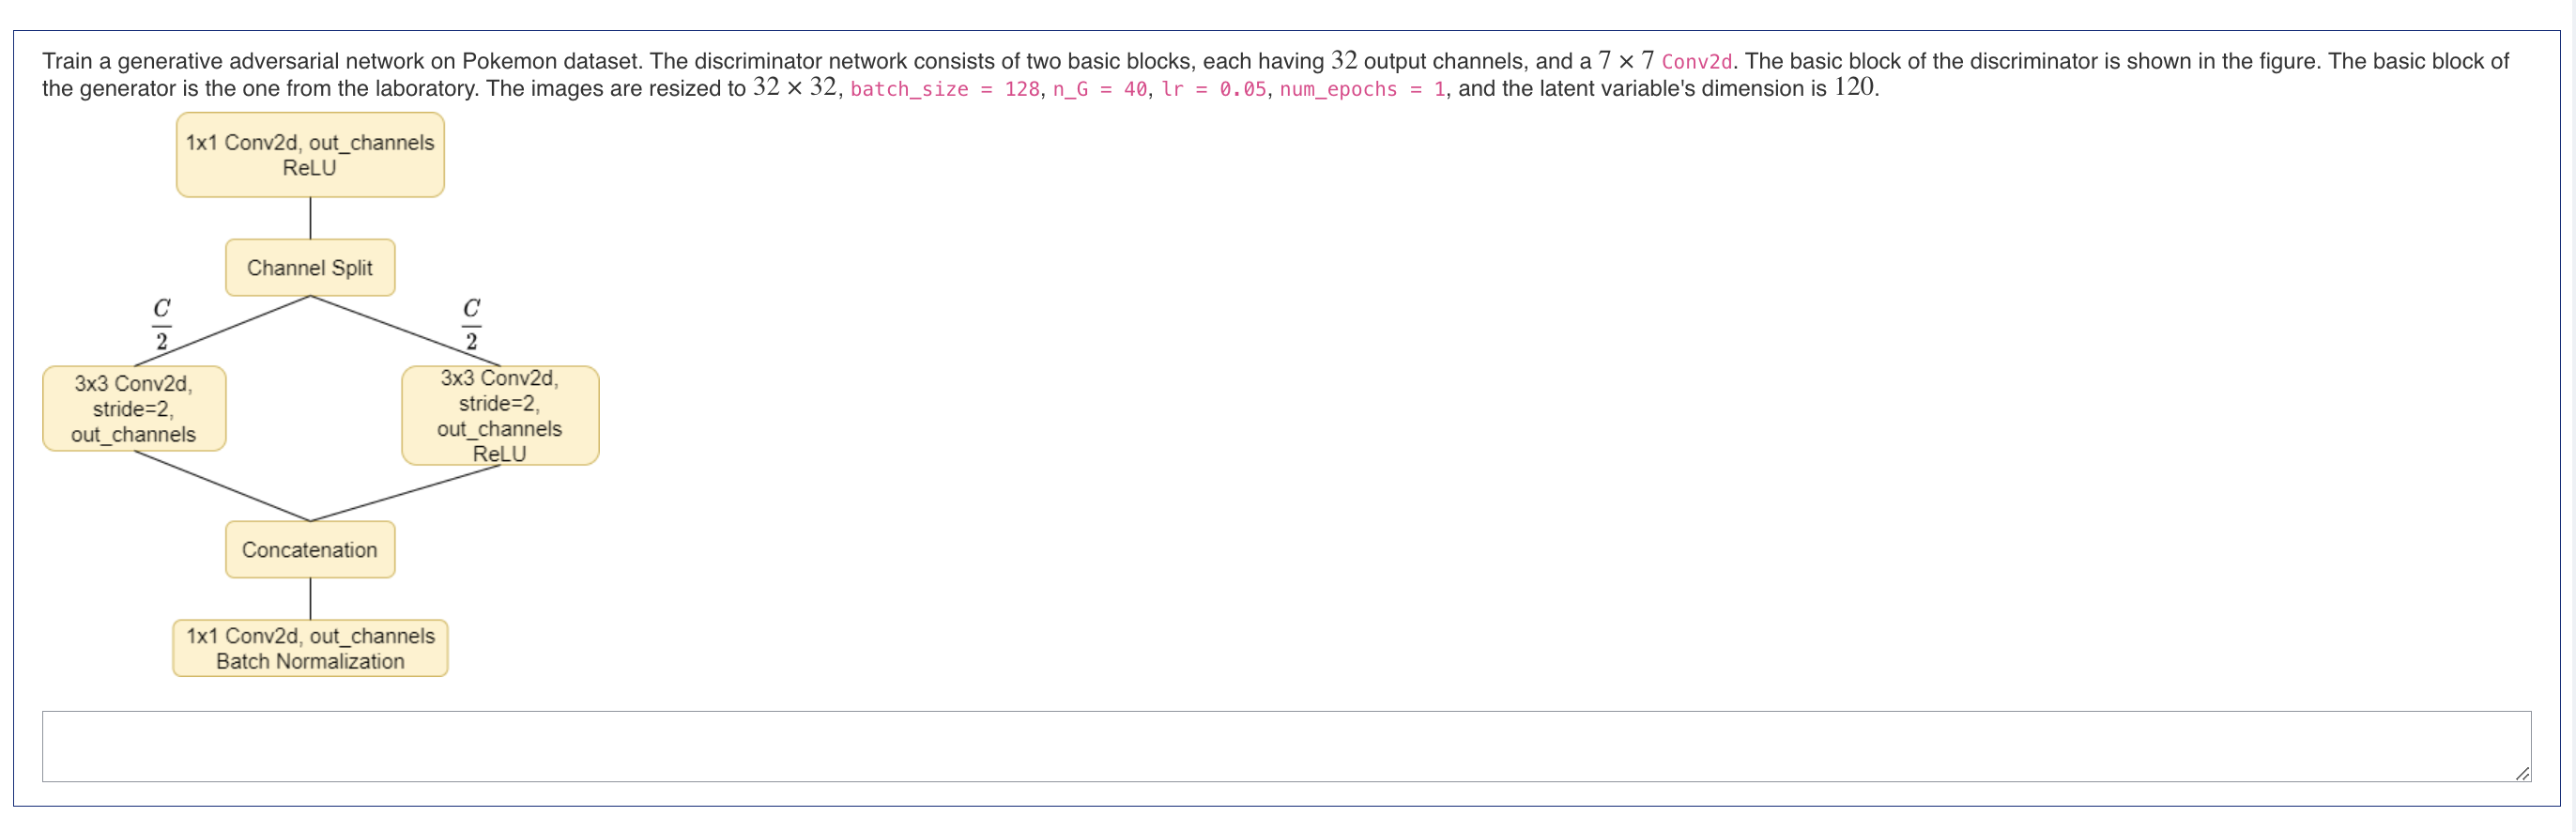

Using device: cuda:0
Download completed.
Epoch [1/25], Loss D: 0.6045, Loss G: 2.9588


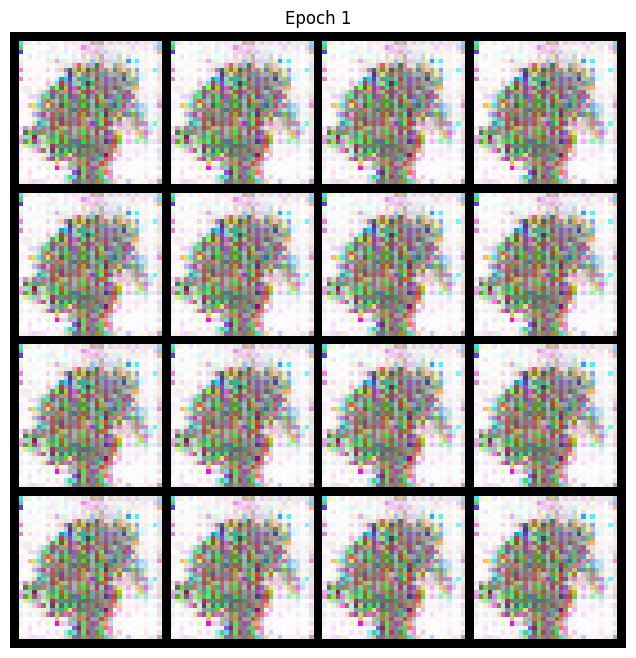

Epoch [2/25], Loss D: 0.6709, Loss G: 1.1072
Epoch [3/25], Loss D: 0.4011, Loss G: 1.6836
Epoch [4/25], Loss D: 0.3979, Loss G: 1.4570
Epoch [5/25], Loss D: 0.5650, Loss G: 0.9259


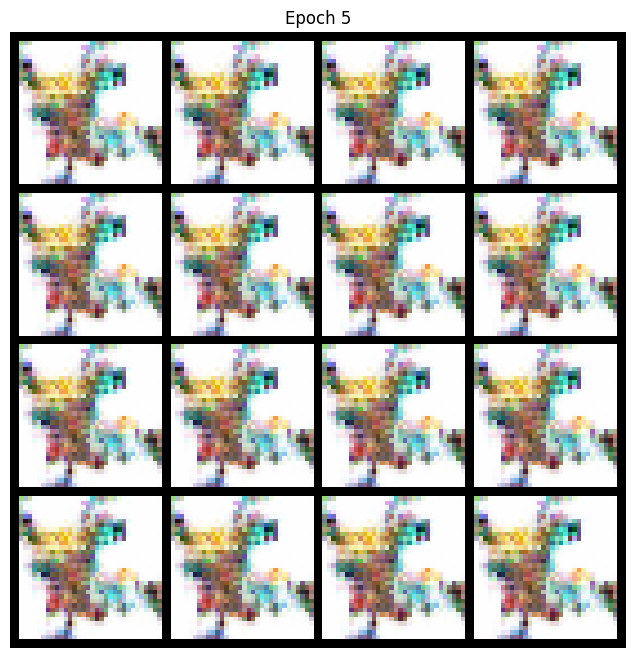

Epoch [6/25], Loss D: 0.8758, Loss G: 0.7459


KeyboardInterrupt: 

In [ ]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

"""
Modified DCGAN Training Script

This script trains a Deep Convolutional Generative Adversarial Network (DCGAN) on the Pokémon dataset.
It includes modifications to ensure that the discriminator outputs match the target label shapes,
and the generator produces images of the desired size.

Requirements:
    - torch
    - torchvision
    - pandas
    - requests
    - matplotlib
    - pillow
"""

import os
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import requests
import zipfile
import matplotlib.pyplot as plt

def try_gpu(i=0):
    """Returns the available device ('cuda' or 'cpu')."""
    return torch.device(f'cuda:{i}') if torch.cuda.device_count() > i else torch.device('cpu')

def download(url, cache_dir='data'):
    """
    Downloads a file from a URL if it doesn't exist in the cache directory.

    Args:
        url (str): URL of the file to download.
        cache_dir (str): Directory to store the downloaded file.

    Returns:
        str: Path to the downloaded file.
    """
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if not os.path.exists(fname):
        print(f"Downloading from {url}...")
        r = requests.get(url, stream=True)
        with open(fname, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1024):
                if chunk:
                    f.write(chunk)
        print("Download completed.")
    else:
        print(f"File {fname} already exists. Skipping download.")
    return fname

def download_extract(url, folder=None):
    """
    Downloads and extracts a ZIP file from a URL.

    Args:
        url (str): URL of the ZIP file.
        folder (str, optional): Specific folder to extract. If None, extracts all contents.

    Returns:
        str: Path to the extracted folder or base directory.
    """
    fname = download(url)
    base_dir = os.path.dirname(fname)
    if fname.endswith('.zip'):
        with zipfile.ZipFile(fname, 'r') as z:
            z.extractall(base_dir)
    if folder:
        return os.path.join(base_dir, folder)
    return base_dir

class GenBasicBlock(nn.Module):
    """Basic block for the generator with two ConvTranspose2d layers."""
    def __init__(self, in_channels, out_channels):
        super(GenBasicBlock, self).__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels*2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_channels*2),
            nn.ReLU(True),
            nn.ConvTranspose2d(out_channels*2, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(True)
        )
    def forward(self, x):
        return self.net(x)

class Generator(nn.Module):
    """Generator network that upsamples from latent space to image space."""
    def __init__(self, latent_dim=120, n_g=40):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            GenBasicBlock(latent_dim, n_g*4),  # Output: [n_g*4, 2, 2]
            GenBasicBlock(n_g*4, n_g*2),       # Output: [n_g*2, 4, 4]
            GenBasicBlock(n_g*2, n_g),         # Output: [n_g, 8, 8]
            GenBasicBlock(n_g, n_g//2),        # Output: [n_g//2, 16, 16]
            nn.ConvTranspose2d(n_g//2, 3, kernel_size=4, stride=2, padding=1, bias=False),  # Output: [3, 32, 32]
            nn.Tanh()
        )
    def forward(self, x):
        return self.main(x)

class DiscBasicBlock(nn.Module):
    """Basic block for the discriminator with two Conv2d layers."""
    def __init__(self, in_channels, out_channels):
        super(DiscBasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.relu1 = nn.ReLU(True)
        self.split = out_channels // 2
        self.conv_left = nn.Conv2d(self.split, self.split, kernel_size=3, stride=2, padding=1)
        self.relu_left = nn.ReLU(True)
        self.conv_right = nn.Conv2d(self.split, self.split, kernel_size=3, stride=2, padding=1)
        self.relu_right = nn.ReLU(True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn = nn.BatchNorm2d(out_channels)
    def forward(self, x):
        x = self.relu1(self.conv1(x))
        left = x[:, :self.split, :, :]
        right = x[:, self.split:, :, :]
        left = self.relu_left(self.conv_left(left))
        right = self.relu_right(self.conv_right(right))
        x = torch.cat([left, right], dim=1)
        x = self.conv2(x)
        x = self.bn(x)
        return x

class Discriminator(nn.Module):
    """Discriminator network that classifies images as real or fake."""
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            DiscBasicBlock(3, 32),  # Input: [3, 32, 32] -> Output: [32, 16, 16]
            DiscBasicBlock(32, 32), # Input: [32, 16, 16] -> Output: [32, 8, 8]
            nn.Conv2d(32, 1, kernel_size=8, stride=1, padding=0)  # Output: [1, 1, 1]
        )
    def forward(self, x):
        return self.main(x).view(-1, 1)  # Reshape to [batch_size, 1]

def train_dcgan():
    """Function to train the DCGAN."""
    device = try_gpu()
    print(f"Using device: {device}")

    # Download and extract the Pokémon dataset
    data_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/pokemon.zip', 'pokemon')

    # Define transformations for the dataset
    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1]
    ])

    # Create the dataset and dataloader
    dataset = torchvision.datasets.ImageFolder(
        data_dir,
        transform=transform
    )
    data_iter = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=2)

    # Initialize Generator and Discriminator
    latent_dim = 120
    n_g = 40
    lr = 0.0002  # Recommended learning rate for DCGAN
    num_epochs = 25  # Increased epochs for better training

    net_G = Generator(latent_dim=latent_dim, n_g=n_g).to(device)
    net_D = Discriminator().to(device)

    # Loss function
    criterion = nn.BCEWithLogitsLoss()

    # Optimizers
    opt_G = torch.optim.Adam(net_G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(net_D.parameters(), lr=lr, betas=(0.5, 0.999))

    # Training loop
    for epoch in range(num_epochs):
        for X, _ in data_iter:
            bs = X.size(0)
            real_X = X.to(device)
            real_labels = torch.ones(bs, 1, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)

            ### Train Discriminator ###
            opt_D.zero_grad()
            outputs_real = net_D(real_X)
            loss_real = criterion(outputs_real, real_labels)

            # Generate fake images
            z = torch.randn(bs, latent_dim, 1, 1, device=device)
            fake_X = net_G(z)
            outputs_fake = net_D(fake_X.detach())
            loss_fake = criterion(outputs_fake, fake_labels)

            # Total Discriminator loss
            loss_D = (loss_real + loss_fake) / 2
            loss_D.backward()
            opt_D.step()

            ### Train Generator ###
            opt_G.zero_grad()
            outputs_fake_for_G = net_D(fake_X)
            loss_G = criterion(outputs_fake_for_G, real_labels)  # Wants Discriminator to label fakes as real
            loss_G.backward()
            opt_G.step()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")

        # Optional: Save generated images for monitoring
        if (epoch+1) % 5 == 0 or epoch == 0:
            with torch.no_grad():
                z = torch.randn(16, latent_dim, 1, 1, device=device)
                fake_images = net_G(z).cpu()
                grid = torchvision.utils.make_grid(fake_images, nrow=4, normalize=True)
                plt.figure(figsize=(8,8))
                plt.imshow(grid.permute(1, 2, 0))
                plt.title(f"Epoch {epoch+1}")
                plt.axis('off')
                plt.show()

if __name__ == "__main__":
    train_dcgan()


# EX5

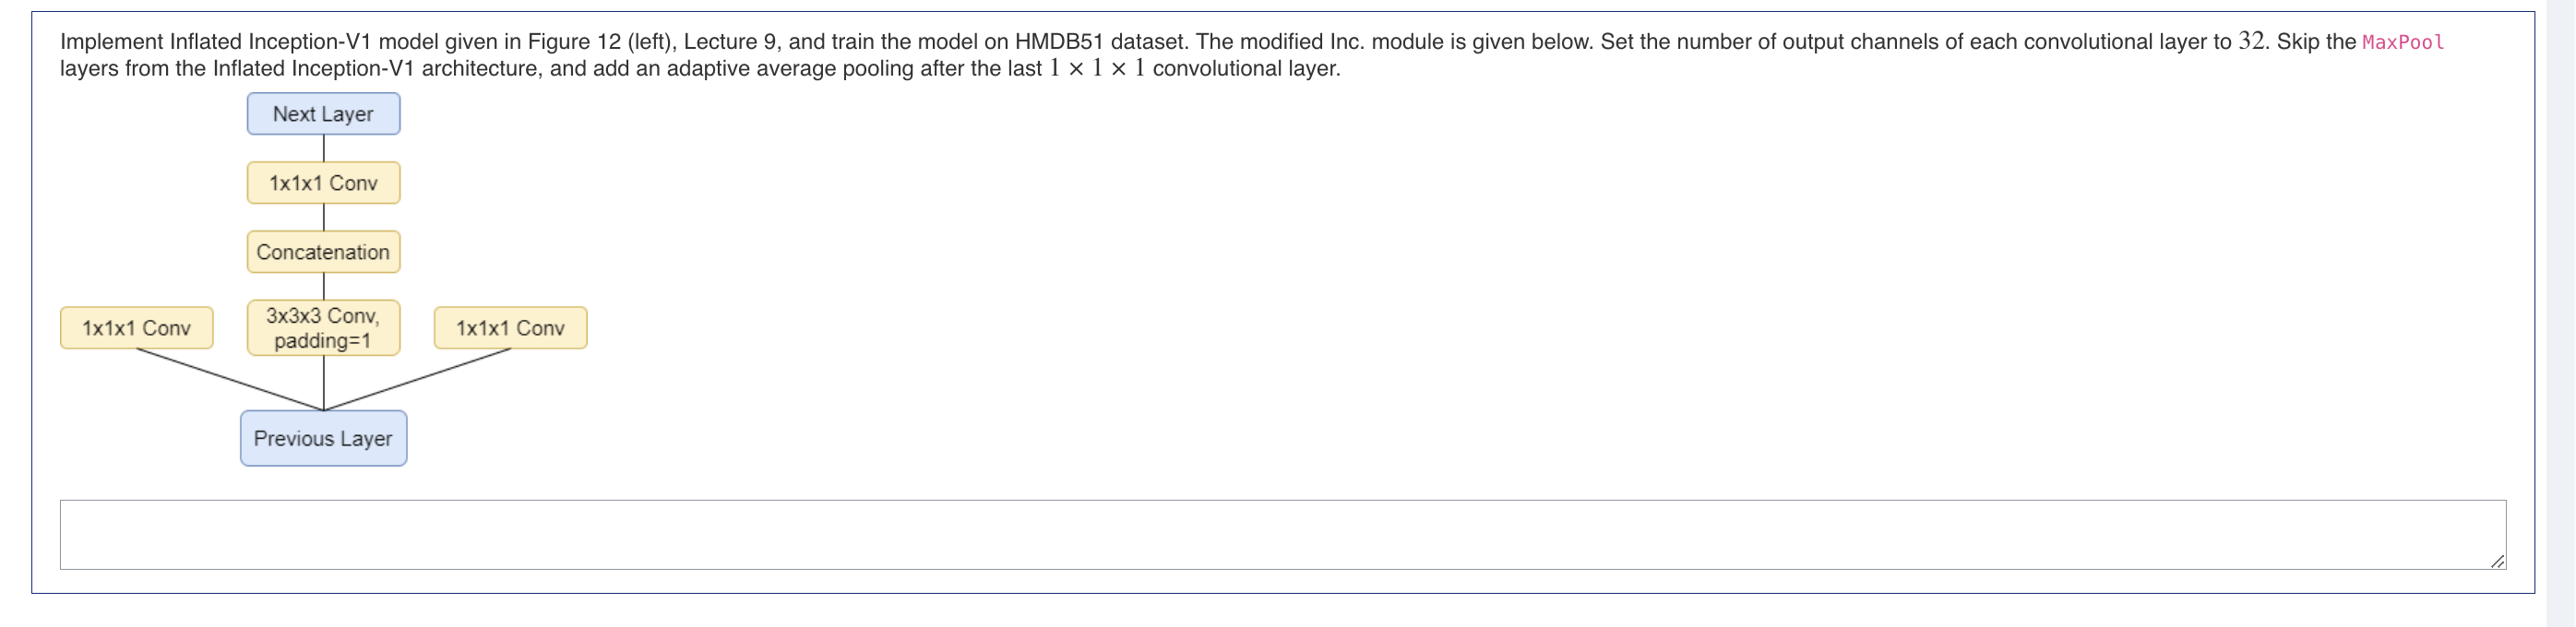

In [ ]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

"""
Video Classification with HMDB51 Dataset

This script performs video classification on the HMDB51 dataset using a custom Inflated InceptionV1 model.

Requirements:
    - torch
    - torchvision
    - pandas
    - requests
    - spacy
    - matplotlib
    - pillow
    - rarfile
"""

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
import pandas as pd
import requests
import zipfile
import rarfile
from io import BytesIO
import warnings
import matplotlib.pyplot as plt

# Suppress warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
torch.manual_seed(42)

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

def download_and_extract(url, extract_to='data'):
    """
    Downloads and extracts a ZIP or RAR file from the given URL.

    Args:
        url (str): URL to download the file from.
        extract_to (str): Directory to extract the contents to.
    """
    local_filename = url.split('/')[-1]
    local_filepath = os.path.join(extract_to, local_filename)

    if not os.path.exists(extract_to):
        os.makedirs(extract_to, exist_ok=True)

    if not os.path.exists(local_filepath):
        print(f"Downloading from {url}...")
        response = requests.get(url, stream=True)
        if response.status_code == 200:
            with open(local_filepath, 'wb') as f:
                for chunk in response.iter_content(chunk_size=1024):
                    if chunk:
                        f.write(chunk)
            print("Download completed.")
        else:
            print(f"Failed to download. Status code: {response.status_code}")
            return
    else:
        print(f"File {local_filename} already exists. Skipping download.")

    # Extract the file based on its extension
    if local_filename.endswith('.zip'):
        print(f"Extracting {local_filename}...")
        with zipfile.ZipFile(local_filepath, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print("Extraction completed.")
    elif local_filename.endswith('.rar'):
        print(f"Extracting {local_filename}...")
        try:
            with rarfile.RarFile(local_filepath, 'r') as rar_ref:
                rar_ref.extractall(extract_to)
            print("Extraction completed.")
        except rarfile.Error as e:
            print(f"Error extracting {local_filename}: {e}")
    else:
        print(f"Unknown file format for {local_filename}. Skipping extraction.")

class ModifiedIncBlock(nn.Module):
    """Basic block for the Inflated InceptionV1 model."""
    def __init__(self, in_channels=32):
        super(ModifiedIncBlock, self).__init__()
        self.branch1 = nn.Sequential(
            nn.Conv3d(in_channels, 32, kernel_size=1, bias=False),
            nn.ReLU(True)
        )
        self.branch2 = nn.Sequential(
            nn.Conv3d(in_channels, 32, kernel_size=3, padding=1, bias=False),
            nn.ReLU(True)
        )
        self.branch3 = nn.Sequential(
            nn.Conv3d(in_channels, 32, kernel_size=1, bias=False),
            nn.ReLU(True)
        )

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        return torch.cat([b1, b2, b3], dim=1)

class InflatedInceptionV1(nn.Module):
    """Custom Inflated Inception V1 model for video classification."""
    def __init__(self, num_classes=51):
        super(InflatedInceptionV1, self).__init__()
        self.conv1 = nn.Conv3d(3, 32, kernel_size=(7,7,7), stride=(2,2,2), padding=(3,3,3), bias=False)
        self.bn1 = nn.BatchNorm3d(32)
        self.relu = nn.ReLU(True)
        self.inc1 = ModifiedIncBlock(32)          # Output channels: 32*3=96
        self.inc2 = ModifiedIncBlock(96)          # Output channels: 96*3=288
        self.unify1 = nn.Conv3d(288, 32, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm3d(32)
        self.inc3 = ModifiedIncBlock(32)          # Output channels: 32*3=96
        self.unify2 = nn.Conv3d(96, 32, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm3d(32)
        self.avgpool = nn.AdaptiveAvgPool3d((1,1,1))
        self.fc = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.conv1(x)          # [B, 32, D/2, H/2, W/2]
        x = self.bn1(x)
        x = self.relu(x)
        x = self.inc1(x)           # [B, 96, D/2, H/2, W/2]
        x = self.inc2(x)           # [B, 288, D/2, H/2, W/2]
        x = self.unify1(x)         # [B, 32, D/2, H/2, W/2]
        x = self.bn2(x)
        x = self.relu(x)
        x = self.inc3(x)           # [B, 96, D/2, H/2, W/2]
        x = self.unify2(x)         # [B, 32, D/2, H/2, W/2]
        x = self.bn3(x)
        x = self.relu(x)
        x = self.avgpool(x)        # [B, 32, 1, 1, 1]
        x = x.flatten(1)           # [B, 32]
        x = self.fc(x)             # [B, num_classes]
        return x

def main():
    device = try_gpu()
    print(f"Using device: {device}")

    # Paths - Update these paths accordingly
    hmdb51_path = "video_data"                # Directory containing HMDB51 videos
    split_path = "test_train_splits"         # Directory containing split files

    # Verify that the paths exist
    if not os.path.exists(hmdb51_path):
        print(f"HMDB51 path '{hmdb51_path}' does not exist. Please download and extract the dataset.")
        return

    if not os.path.exists(split_path):
        print(f"Split path '{split_path}' does not exist. Please download and extract the split files.")
        return

    # Define hyperparameters
    batch_size = 4
    num_workers = 2
    num_epochs = 2
    num_classes = 51
    frames_per_clip = 16
    step_between_clips = 5
    val_split = 0.05  # 5% for validation

    # Define transformations for training and testing
    train_transforms = transforms.Compose([
        transforms.Lambda(lambda x: x.permute(0, 3, 1, 2).float() / 255.0),
        transforms.Resize((128, 171)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop((112, 112))
    ])
    test_transforms = transforms.Compose([
        transforms.Lambda(lambda x: x.permute(0, 3, 1, 2).float() / 255.0),
        transforms.Resize((128, 171)),
        transforms.CenterCrop((112, 112))
    ])

    # Load HMDB51 training and testing datasets
    train_dataset = torchvision.datasets.HMDB51(
        root=hmdb51_path,
        annotation_path=split_path,
        frames_per_clip=frames_per_clip,
        step_between_clips=step_between_clips,
        fold=1,
        train=True,
        transform=train_transforms
    )

    test_dataset = torchvision.datasets.HMDB51(
        root=hmdb51_path,
        annotation_path=split_path,
        frames_per_clip=frames_per_clip,
        step_between_clips=step_between_clips,
        fold=1,
        train=False,
        transform=test_transforms
    )

    # Split training data into training and validation
    total_train_samples = len(train_dataset)
    total_val_samples = round(val_split * total_train_samples)
    total_train_final = total_train_samples - total_val_samples

    train_dataset_final, val_dataset = random_split(train_dataset, [total_train_final, total_val_samples])

    # Create DataLoaders
    train_loader = DataLoader(train_dataset_final, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    print(f"Number of train samples: {total_train_final}")
    print(f"Number of validation samples: {total_val_samples}")
    print(f"Number of test samples: {len(test_dataset)}")

    # Define the model
    model = InflatedInceptionV1(num_classes=num_classes).to(device)

    # Define optimizer and loss function
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    def train_one_epoch(model, loader, optimizer, criterion, epoch):
        """Train the model for one epoch."""
        model.train()
        running_loss = 0.0
        total_correct = 0
        total_samples = 0
        for i, data in enumerate(loader):
            vids, labels = data[0], data[1]
            vids = vids.permute(0, 2, 1, 3, 4).to(device)  # [B, C, D, H, W]
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(vids)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * vids.size(0)
            _, preds = torch.max(outputs, dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += vids.size(0)

            if (i + 1) % 100 == 0:
                current_loss = running_loss / total_samples
                current_acc = 100.0 * total_correct / total_samples
                print(f"Train Epoch: {epoch} Batch [{i+1}/{len(loader)} ({100.0*(i+1)/len(loader):.0f}%)]\tLoss: {current_loss:.6f} Accuracy: {total_correct}/{total_samples} ({current_acc:.0f}%)")

        average_loss = running_loss / total_samples
        average_acc = 100.0 * total_correct / total_samples
        print(f"Train Epoch: {epoch} Average Loss: {average_loss:.6f} Average Accuracy: {total_correct}/{total_samples} ({average_acc:.2f}%)")

    def evaluate(model, loader, criterion, text='Validation'):
        """Evaluate the model."""
        model.eval()
        running_loss = 0.0
        total_correct = 0
        total_samples = 0
        with torch.no_grad():
            for data in loader:
                vids, labels = data[0], data[1]
                vids = vids.permute(0, 2, 1, 3, 4).to(device)  # [B, C, D, H, W]
                labels = labels.to(device)

                outputs = model(vids)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * vids.size(0)
                _, preds = torch.max(outputs, dim=1)
                total_correct += (preds == labels).sum().item()
                total_samples += vids.size(0)

        average_loss = running_loss / total_samples
        average_acc = 100.0 * total_correct / total_samples
        print(f"{text} Average Loss: {average_loss:.6f} Average Accuracy: {total_correct}/{total_samples} ({average_acc:.2f}%)")

    # Training loop
    for epoch in range(1, num_epochs + 1):
        train_one_epoch(model, train_loader, optimizer, criterion, epoch)
        evaluate(model, val_loader, criterion, text="Validation")
        evaluate(model, test_loader, criterion, text="Test")

if __name__ == "__main__":
    main()


ModuleNotFoundError: No module named 'rarfile'